# \(K^{0}_{S}\rightarrow\pi^{+}\pi^{-}\) tracking QA

This notebook focuses on the signed daughter offset relative to the reconstructed secondary vertex and on cluster residuals.

Important distinction:

- `h_dca_xy_to_primary_vertex`, `h_dca_z_to_primary_vertex`: DCA to the configured **primary** vertex;
- `secondary_dca_xy`, `secondary_dca_z`: daughter PCA displacement from the reconstructed \(K^{0}_{S}\) midpoint.

For `cut03_baseline`, \(|pca1_z-pca2_z|<0.50\) implies \(|secondary\_dca_z|<0.25\) cm. It does not restrict primary-vertex `dca_z`.


In [1]:
from pathlib import Path
import ROOT as root

#root.gROOT.SetBatch(True)
root.gStyle.SetOptStat(0)
root.gStyle.SetOptTitle(0)
root.gStyle.SetPalette(root.kBird)
root.gStyle.SetPadTickX(1)
root.gStyle.SetPadTickY(1)

input_file = Path("input/k0s_pp_pion_qa_v2.root")
output_dir = Path("output_pair/k0s_pion_tracking_qa")
output_dir.mkdir(parents=True, exist_ok=True)

cut = "cut03_baseline"
region = "signal_0p47_0p53"
category = "all"

safe_to_pdf = False

pt_ranges = [
    (0.20, 1.00),
    (1.00, 2.00),
    (2.00, 6.00),
]

root_file = root.TFile.Open(str(input_file), "READ")
if not root_file or root_file.IsZombie():
    raise RuntimeError(f"Could not open {input_file}")


Welcome to JupyROOT 6.30/06


In [2]:
keep_objects = []
canvases = []

def keep(obj):
    keep_objects.append(obj)
    return obj

def path(hist_name, category_name=category):
    return f"{cut}/{region}/daughters/{category_name}/{hist_name}"

def clone(hist_path, tag):
    obj = root_file.Get(hist_path)
    if not obj:
        raise KeyError(hist_path)
    copied = obj.Clone(f"{obj.GetName()}_{tag}_{len(keep_objects)}")
    copied.SetDirectory(0)
    return keep(copied)

def set_pad(logz=False, logy=False, right=0.05):
    root.gPad.SetLeftMargin(0.14)
    root.gPad.SetBottomMargin(0.14)
    root.gPad.SetRightMargin(right)
    root.gPad.SetTopMargin(0.07)
    root.gPad.SetLogz(logz)
    root.gPad.SetLogy(logy)

def project_pt(hist_path, pt_min, pt_max, option="yx", tag="projection"):
    source = clone(hist_path, f"source_{tag}")
    first = source.GetZaxis().FindBin(pt_min + 1e-9)
    last = source.GetZaxis().FindBin(pt_max - 1e-9)
    source.GetZaxis().SetRange(first, last)
    result = source.Project3D(option)
    result.SetName(f"{source.GetName()}_{option}_{tag}")
    result.SetDirectory(0)
    return keep(result)

def draw_label(text):
    label = keep(root.TLatex())
    label.SetNDC(True)
    label.SetTextSize(0.032)
    label.DrawLatex(0.16, 0.93, text)

def save(canvas, name):
    canvases.append(canvas)
    if safe_to_pdf:
        canvas.SaveAs(str(output_dir / f"{name}.pdf"))


## Secondary DCA basic checks

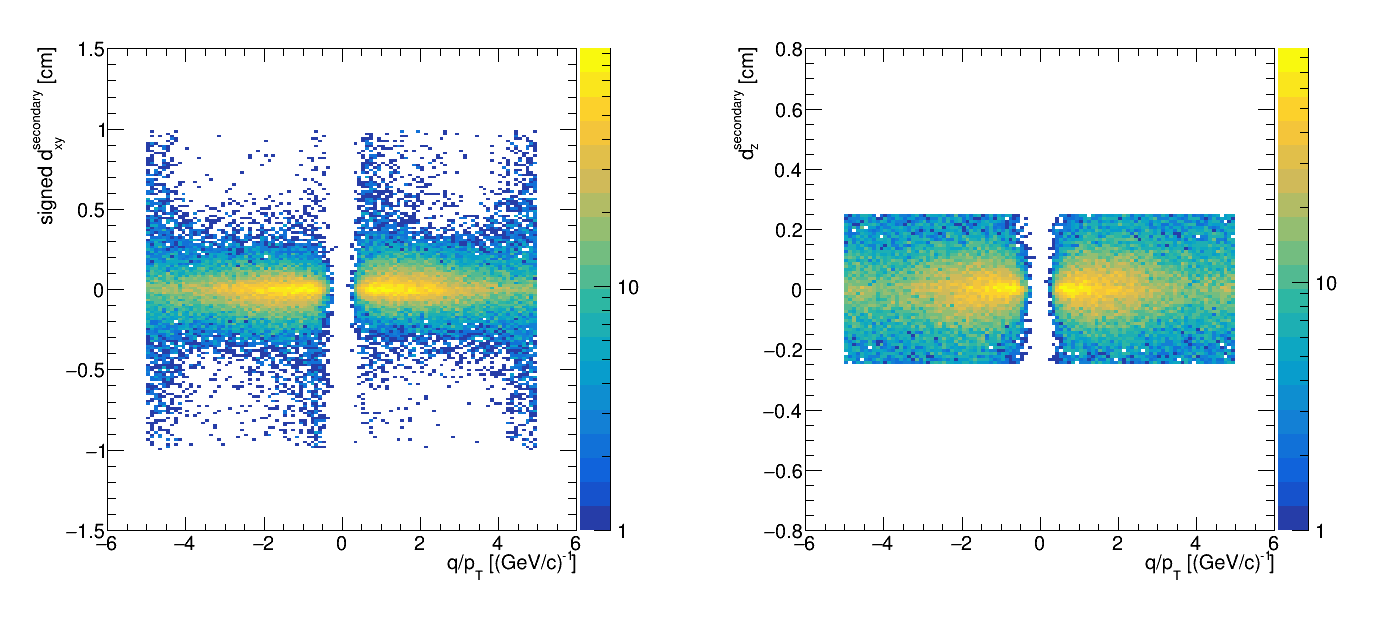

In [3]:
c_secondary_basic = keep(root.TCanvas("c_secondary_basic", "c_secondary_basic", 1400, 650))
c_secondary_basic.Divide(2, 1)

for ipad, hist_name in enumerate([
    "h_secondary_dca_xy_vs_q_over_pt",
    "h_secondary_dca_z_vs_q_over_pt",
], start=1):
    c_secondary_basic.cd(ipad)
    set_pad(logz=True, right=0.16)
    hist = clone(path(hist_name), f"basic_{ipad}")
    hist.SetMinimum(1.0)
    hist.Draw("COLZ")

c_secondary_basic.Update()
save(c_secondary_basic, "secondary_dca_vs_qoverpt")
c_secondary_basic


## Secondary DCA versus phi/eta in pT slices

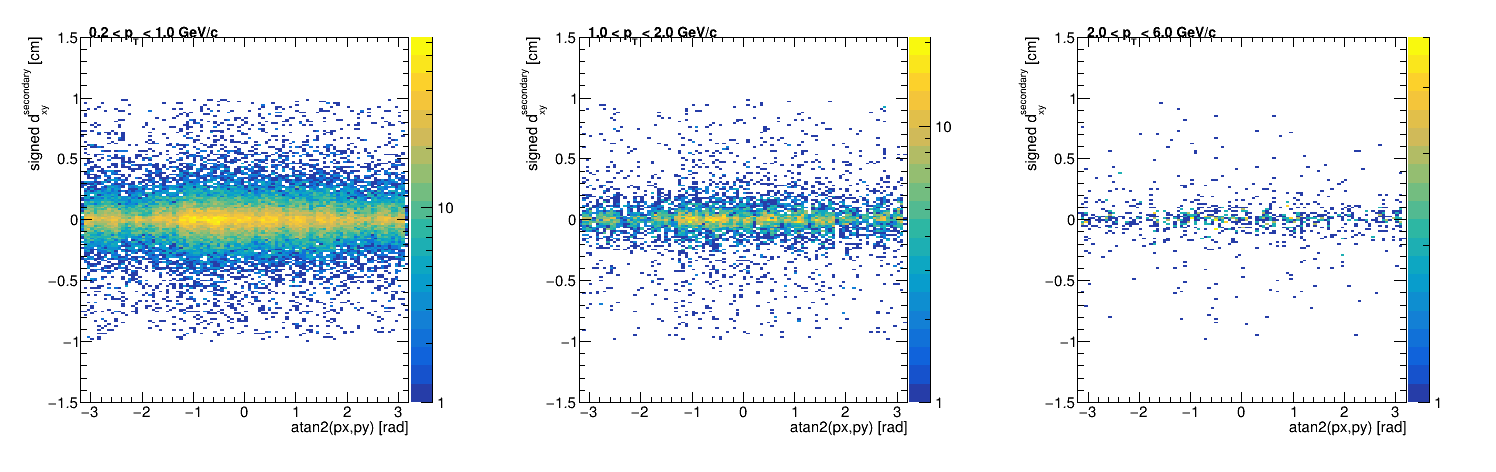

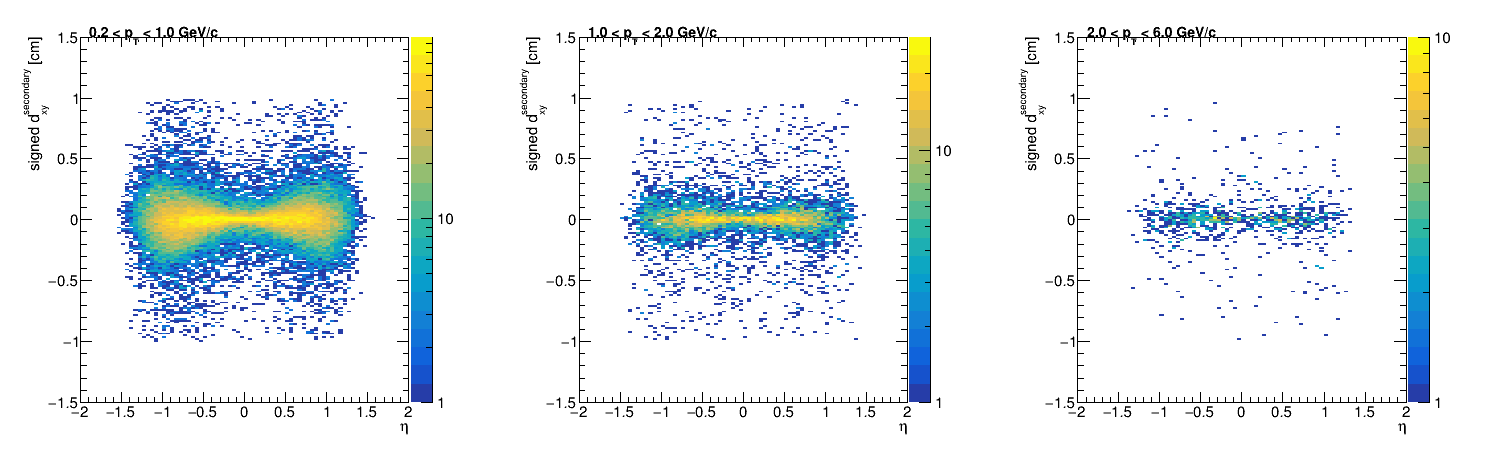

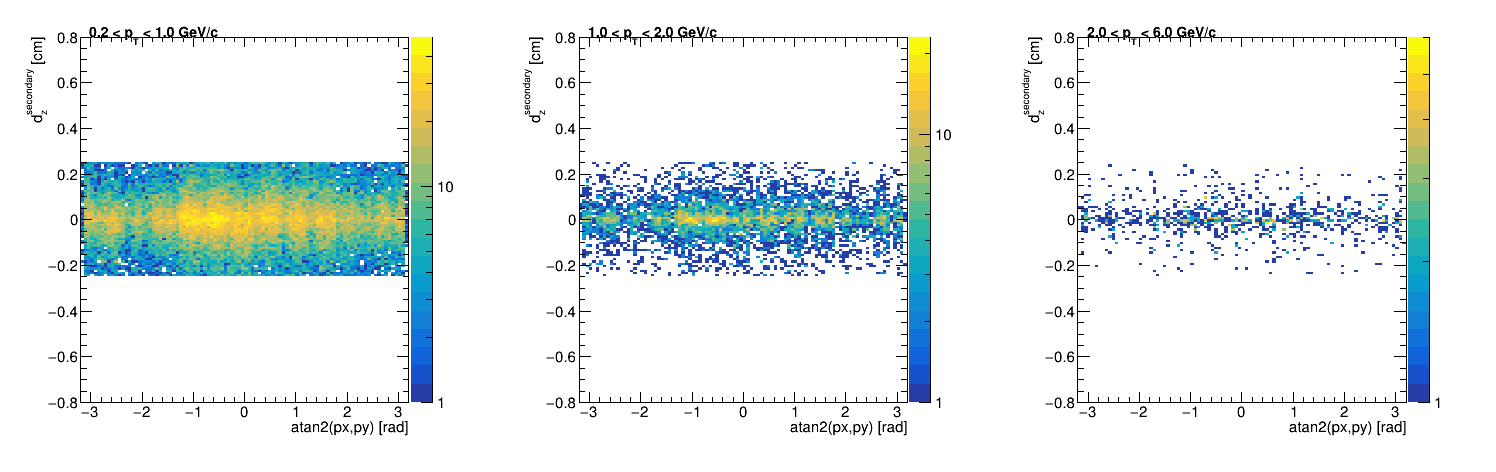

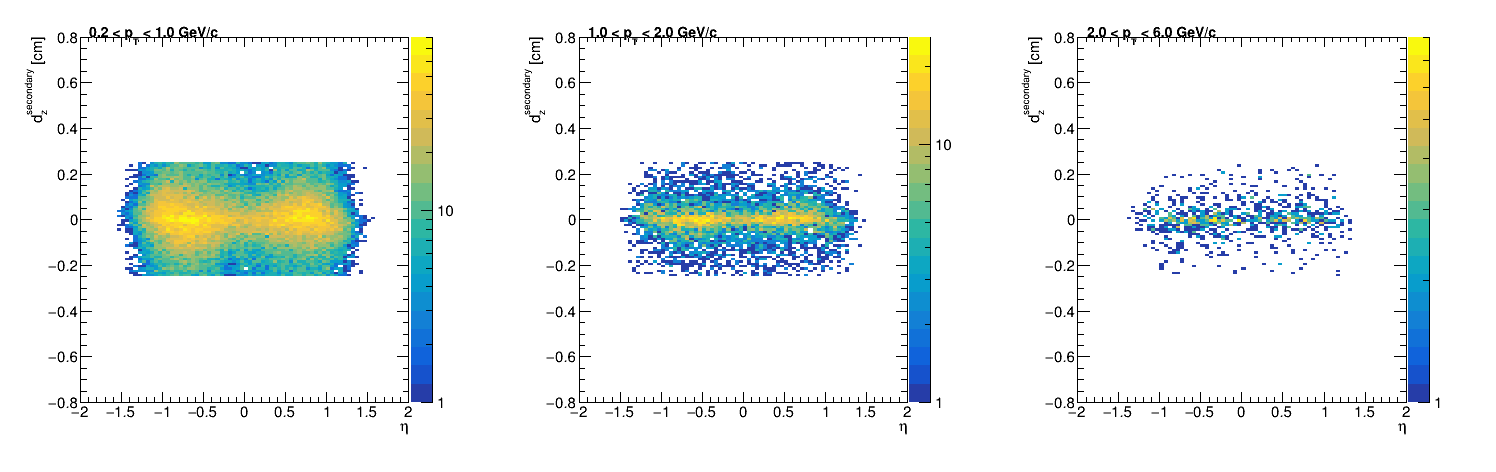

In [4]:
histograms = [
    "h_secondary_dca_xy_vs_phi_vs_pt",
    "h_secondary_dca_xy_vs_eta_vs_pt",
    "h_secondary_dca_z_vs_phi_vs_pt",
    "h_secondary_dca_z_vs_eta_vs_pt",
]

for hist_name in histograms:
    canvas = keep(root.TCanvas(f"c_{hist_name}", f"c_{hist_name}", 1500, 500))
    canvas.Divide(3, 1)

    for ipad, (pt_min, pt_max) in enumerate(pt_ranges, start=1):
        canvas.cd(ipad)
        set_pad(logz=True, right=0.16)
        hist = project_pt(
            path(hist_name),
            pt_min,
            pt_max,
            option="yx",
            tag=f"{ipad}",
        )
        hist.SetMinimum(1.0)
        hist.Draw("COLZ")
        draw_label(f"{pt_min:.1f} < p_{{T}} < {pt_max:.1f} GeV/c")

    canvas.Update()
    save(canvas, hist_name)

canvas


## Mean secondary DCA maps versus phi and eta

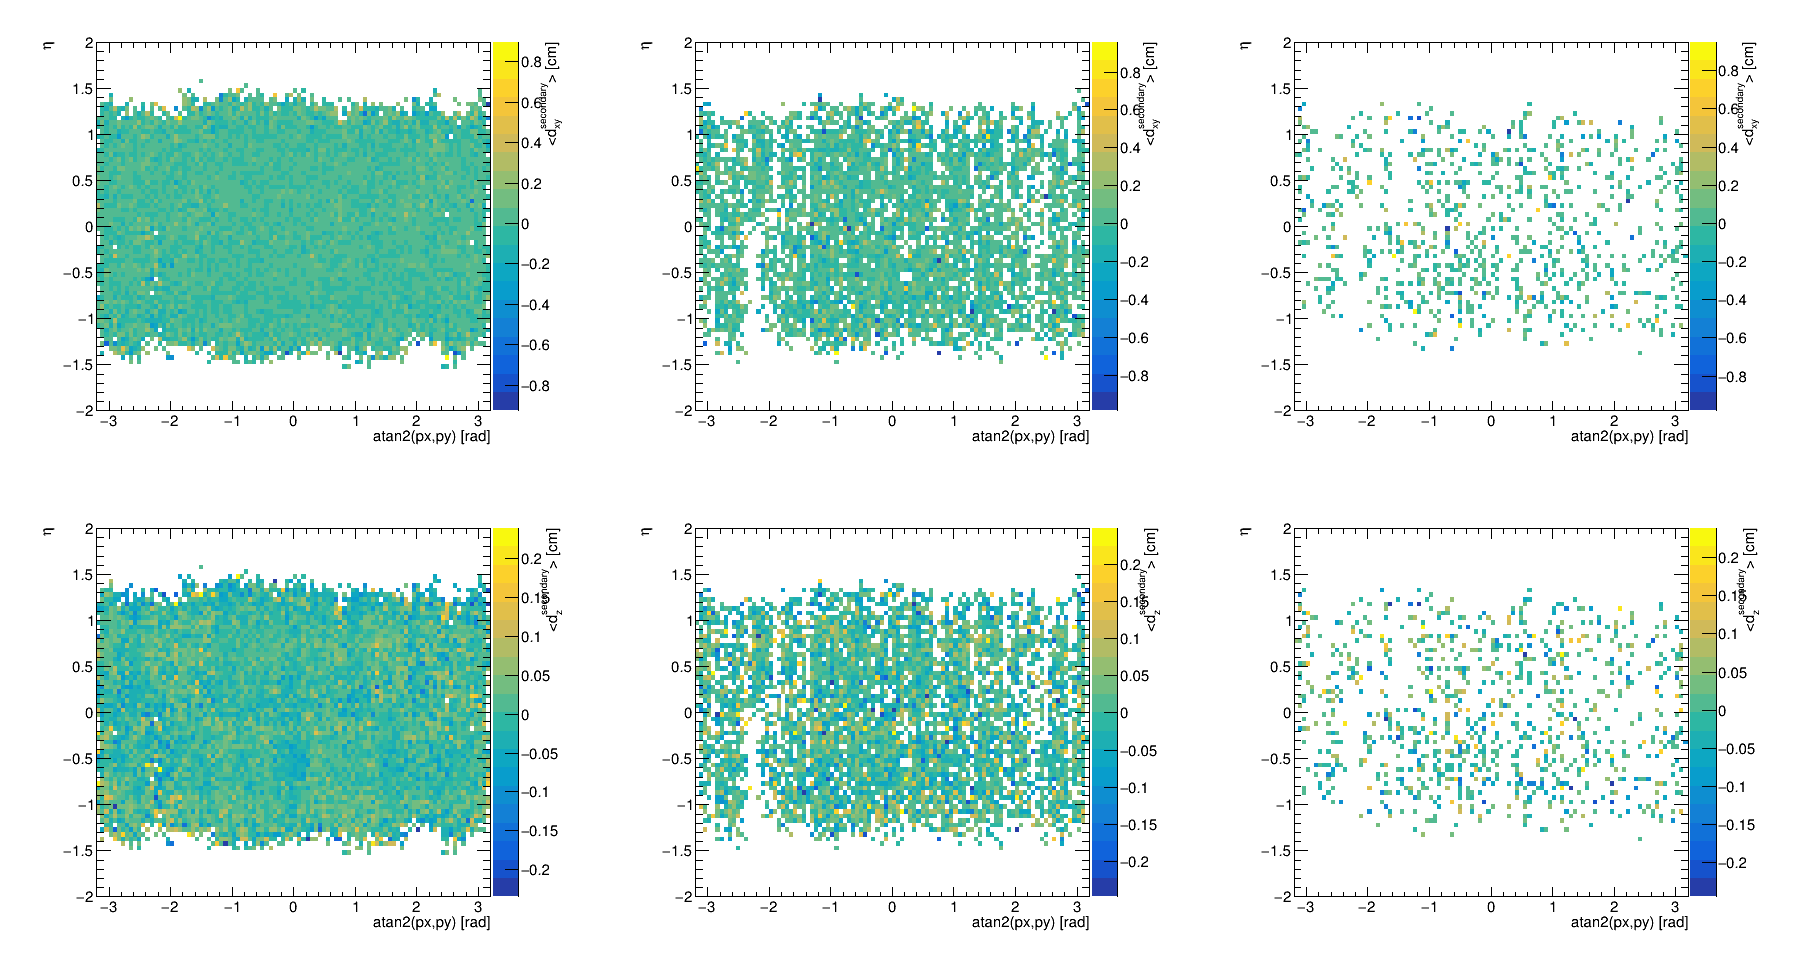

In [5]:
profile_names = [
    "p_secondary_dca_xy_phi_eta_pt0p2",
    "p_secondary_dca_xy_phi_eta_pt1",
    "p_secondary_dca_xy_phi_eta_pt2",
    "p_secondary_dca_z_phi_eta_pt0p2",
    "p_secondary_dca_z_phi_eta_pt1",
    "p_secondary_dca_z_phi_eta_pt2",
]

c_secondary_profiles = keep(root.TCanvas(
    "c_secondary_profiles",
    "c_secondary_profiles",
    1800,
    1000,
))
c_secondary_profiles.Divide(3, 2)

for ipad, hist_name in enumerate(profile_names, start=1):
    c_secondary_profiles.cd(ipad)
    set_pad(right=0.16)
    hist = clone(path(hist_name), f"profile_{ipad}")
    hist.Draw("COLZ")

c_secondary_profiles.Update()
save(c_secondary_profiles, "secondary_dca_phi_eta_profiles")
c_secondary_profiles


## rphi and z residuals versus detector coordinate and pT

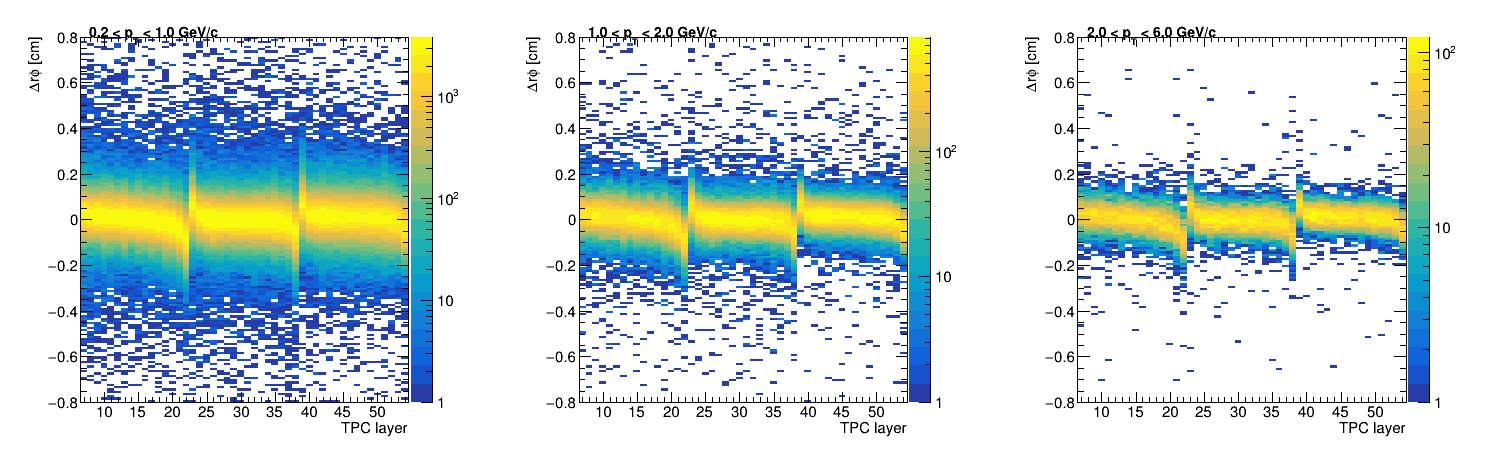

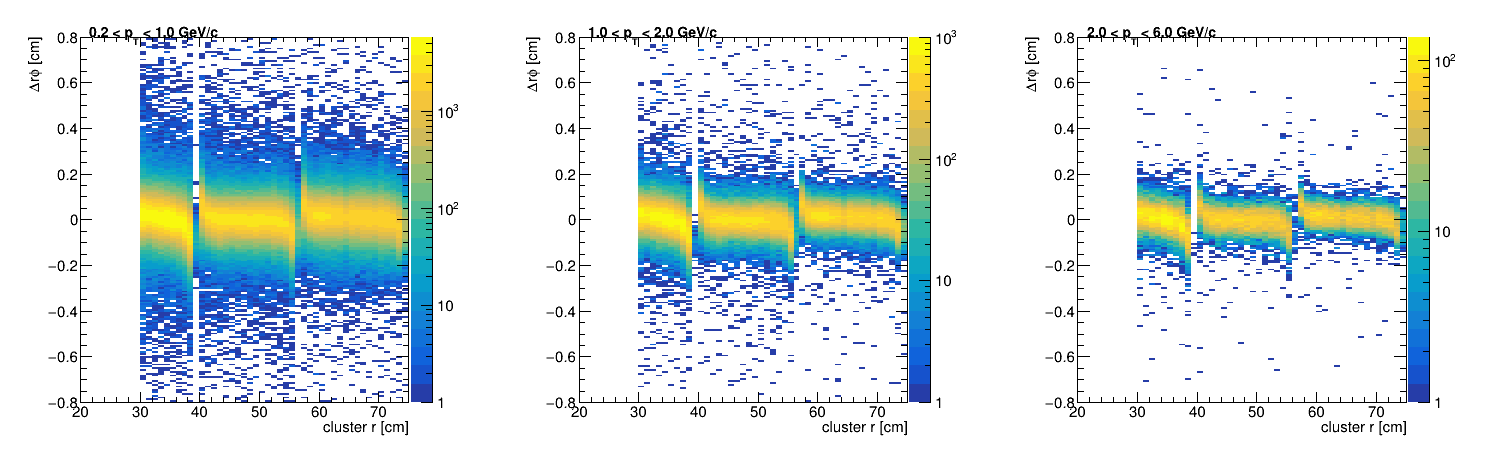

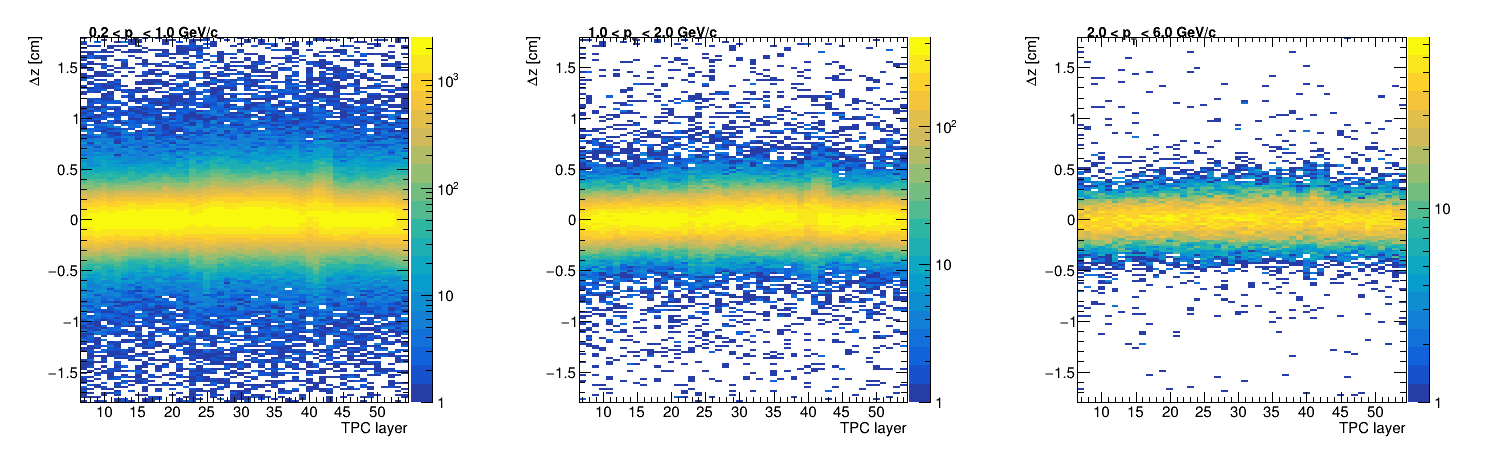

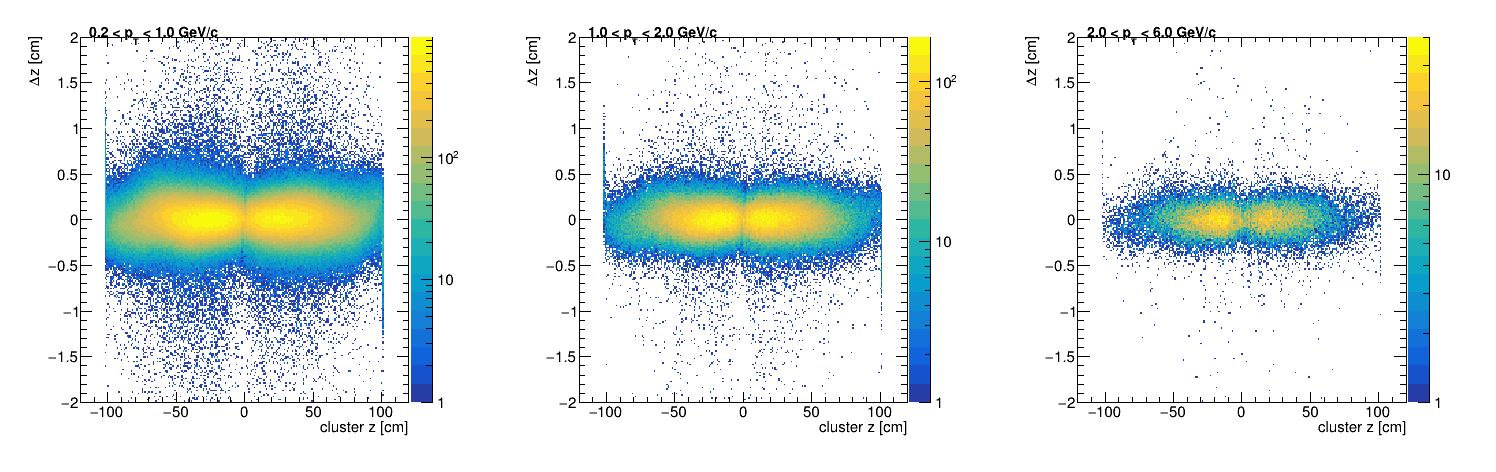

In [6]:
residual_histograms = [
    "h_residual_rphi_vs_layer_vs_pt",
    "h_residual_rphi_vs_cluster_r_vs_pt",
    "h_residual_z_vs_layer_vs_pt",
    "h_residual_z_vs_cluster_z_vs_pt",
]

for hist_name in residual_histograms:
    canvas = keep(root.TCanvas(f"c_{hist_name}", f"c_{hist_name}", 1500, 500))
    canvas.Divide(3, 1)

    for ipad, (pt_min, pt_max) in enumerate(pt_ranges, start=1):
        canvas.cd(ipad)
        set_pad(logz=True, right=0.16)
        hist = project_pt(
            path(hist_name),
            pt_min,
            pt_max,
            option="yx",
            tag=f"{ipad}",
        )
        hist.SetMinimum(1.0)
        hist.Draw("COLZ")
        draw_label(f"{pt_min:.1f} < p_{{T}} < {pt_max:.1f} GeV/c")

    canvas.Update()
    save(canvas, hist_name)

canvas


## Mean residual maps versus track phi and eta

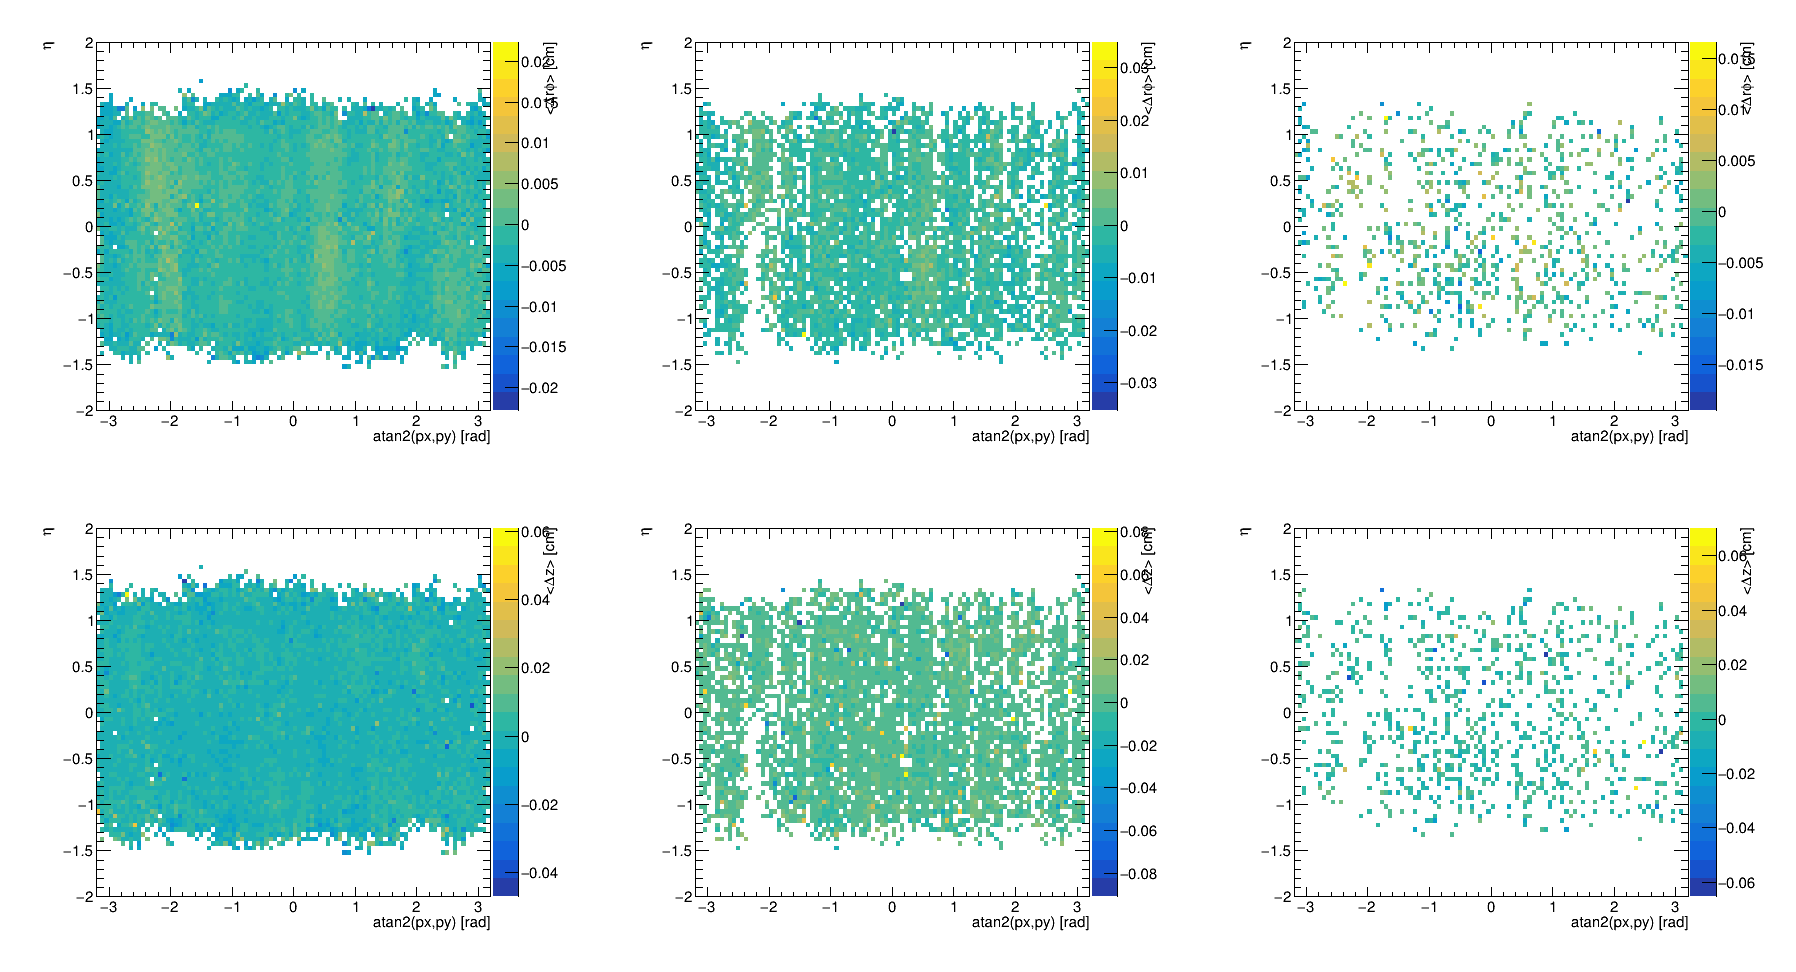

In [7]:
profile_names = [
    "p_residual_rphi_phi_eta_pt0p2",
    "p_residual_rphi_phi_eta_pt1",
    "p_residual_rphi_phi_eta_pt2",
    "p_residual_z_phi_eta_pt0p2",
    "p_residual_z_phi_eta_pt1",
    "p_residual_z_phi_eta_pt2",
]

c_residual_profiles = keep(root.TCanvas(
    "c_residual_profiles",
    "c_residual_profiles",
    1800,
    1000,
))
c_residual_profiles.Divide(3, 2)

for ipad, hist_name in enumerate(profile_names, start=1):
    c_residual_profiles.cd(ipad)
    set_pad(right=0.16)
    hist = clone(path(hist_name), f"res_profile_{ipad}")
    hist.Draw("COLZ")

c_residual_profiles.Update()
save(c_residual_profiles, "residual_phi_eta_profiles")
c_residual_profiles


## Interpretation

- `secondary_dca_z` outside \(\pm0.25\) cm for `cut03_baseline` indicates a definition/filling error.
- `secondary_dca_xy` should be bounded approximately by half the daughter-pair PCA separation because the pair vertex is their midpoint.
- A charge-dependent slope versus \(q/p_T\) points to curvature or field/alignment effects.
- A fixed phi structure points to detector distortions or alignment.
- A strong low-\(p_T\) dependence points toward multiple scattering, process noise, or outlier rejection.
- Residual structures localized in layer or cluster radius point toward region boundaries or layer-dependent measurement uncertainties.
